# CodeLab 5. Многослойная нейронная сеть

В этом задании вам предстоит:
- реализовать слои ReLU и FullyConnected;
- составить из них нейронную сеть;
- переобучить сеть на небольшом наборе данных
- обучить модель на полной выборке и получить точность > 40%


In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

## Загрузка датасета CIFAR-10 и нормализация данных

In [2]:
# Очистим значения переменных, чтобы избежать проблем с излишним потреблением памяти
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


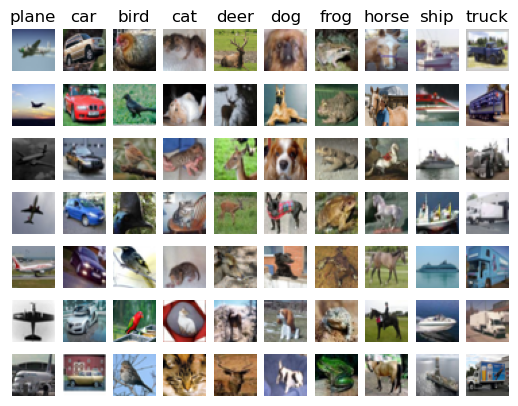

In [3]:
# Перед началом работы полезно посмотреть на данные.
# Отобразим пример из каждого класса.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Для удобства преобразуем двумерные изображения в одномерные вектора fp64
X_train = np.reshape(X_train, (X_train.shape[0], -1)).astype(np.float64)
X_test = np.reshape(X_test, (X_test.shape[0], -1)).astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Test data shape:  (10000, 3072)
Training label shape:  (50000,)
Test label shape:  (10000,)


In [5]:
# Разделим данные на выборки train, val, test

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 16

# Для валидации используем подвыборку train
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# На остальных данных из train будем тренировать модель
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Чтобы ускорить разработку, создадим также небольшую dev выборку 
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Для тестирования используем оригинальную выборку test
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


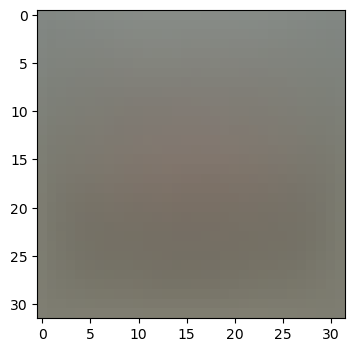

(49000, 3072) (1000, 3072) (1000, 3072) (16, 3072)


In [6]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

# Вычтем средние значения яркости
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image


print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Функции для сравнения аналитического градиента с градиентом, вычисленного методом конечных разностей. 

In [7]:
def check_gradient(f, x, delta=1e-5, tol=1e-4):
    """
    Checks the implementation of analytical gradient by comparing
    it to numerical gradient using two-point formula
    Arguments:
      f: function that receives x and computes value and gradient
      x: np array, initial point where gradient is checked
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Return:
      bool indicating whether gradients match or not
    """
    assert isinstance(x, np.ndarray)
    assert np.issubdtype(x.dtype, np.floating)
    
    orig_x = x.copy()
    fx, analytic_grad = f(x)
    assert np.all(np.isclose(orig_x, x, tol)), "Functions shouldn't modify input variables"

    assert analytic_grad.shape == x.shape
    analytic_grad = analytic_grad.copy()
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        analytic_grad_at_ix = analytic_grad[ix]

        x0 = x.copy()
        x1 = x.copy()
        x0[ix] += delta
        x1[ix] -= delta
        
        numeric_grad_at_ix = (f(x0)[0] - f(x1)[0]) / (2 * delta)

        if not np.isclose(numeric_grad_at_ix, analytic_grad_at_ix, atol=tol):
            print("Gradients are different at %s. Analytic: %2.5f, Numeric: %2.5f" % (ix, analytic_grad_at_ix, numeric_grad_at_ix))
            return False

        it.iternext()
    
    print("Gradient check passed!")
    return True


In [8]:
def check_layer_gradient(layer, x, delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for the input and output of a layer
    Arguments:
      layer: neural network layer, with forward and backward functions
      x: starting point for layer input
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Returns:
      bool indicating whether gradients match or not
    """
    output = layer.forward(x)
    output_weight = np.random.randn(*output.shape)

    def helper_func(x):
        output = layer.forward(x)
        loss = np.sum(output * output_weight)
        d_out = np.ones_like(output) * output_weight
        grad = layer.backward(d_out)
        return loss, grad

    return check_gradient(helper_func, x, delta, tol)

In [9]:
def check_layer_param_gradient(layer, x,
                               param_name,
                               delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for the parameter of the layer
    Arguments:
      layer: neural network layer, with forward and backward functions
      x: starting point for layer input
      param_name: name of the parameter
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Returns:
      bool indicating whether gradients match or not
    """
    param = layer.params()[param_name]
    initial_w = param.value

    output = layer.forward(x)
    output_weight = np.random.randn(*output.shape)

    def helper_func(w):
        param.value = w
        output = layer.forward(x)
        loss = np.sum(output * output_weight)
        d_out = np.ones_like(output) * output_weight
        layer.backward(d_out)
        grad = param.grad
        return loss, grad

    return check_gradient(helper_func, initial_w, delta, tol)

In [10]:
def check_model_gradient(model, X, y,
                         delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for all model parameters
    Arguments:
      model: neural network model with compute_loss_and_gradients
      X: batch of input data
      y: batch of labels
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient
    Returns:
      bool indicating whether gradients match or not
    """
    params = model.params()

    for param_key in params:
        print("Checking gradient for %s" % param_key)
        param = params[param_key]
        initial_w = param.value

        def helper_func(w):
            param.value = w
            loss = model.compute_loss_and_gradients(X, y)
            grad = param.grad
            return loss, grad

        if not check_gradient(helper_func, initial_w, delta, tol):
            return False

    return True

## Задание 1. ReLU Layer

Мы будем реализовывать необходимые нам слои по очереди. Каждый слой должен реализовать:
- прямой проход (forward pass), который генерирует выход слоя по входу и запоминает необходимые данные
- обратный проход (backward pass), который получает градиент по выходу слоя и вычисляет градиент по входу и по параметрам

Начнем с ReLU, у которого обучаемых параметров нет.

In [11]:
class ReLULayer:
    def __init__(self):
        self.mask = None

    def forward(self, X):
        self.mask = X > 0
        return np.maximum(X, 0)

    def backward(self, d_out):
        """
        Backward pass
        Arguments:
        d_out, np array (batch_size, num_features) - gradient
           of loss function with respect to output
        Returns:
        d_result: np array (batch_size, num_features) - gradient
          with respect to input
        """
        return d_out * self.mask
        

    def params(self):
        # ReLU Doesn't have any parameters
        return {}


In [12]:
# Проверка реализации ReLULayer 
# Note: you'll need to copy implementation of the gradient_check function from the previous assignment

X = np.array([[1,-2,3],
              [-1, 2, 0.1]
              ])

assert check_layer_gradient(ReLULayer(), X)

Gradient check passed!


## Задание 2. FullyConnected (Dense) Layer

А теперь реализуем полносвязный слой (fully connected layer), у которого будет два массива параметров: W (weights) и B (bias).

Все параметры наши слои будут использовать для параметров специальный класс `Param`, в котором будут храниться значения параметров и градиенты этих параметров, вычисляемые во время обратного прохода.

Это даст возможность аккумулировать (суммировать) градиенты из разных частей функции потерь, например, из cross-entropy loss и regularization loss.

In [13]:
class Param:
    """
    Trainable parameter of the model
    Captures both parameter value and the gradient
    """

    def __init__(self, value):
        self.value = value
        self.grad = np.zeros_like(value)

In [14]:
class FullyConnectedLayer:
    def __init__(self, n_input, n_output):
        self.W = Param(0.001 * np.random.randn(n_input, n_output))
        self.B = Param(0.001 * np.random.randn(1, n_output))
        self.X = None

    def forward(self, X):
        self.X = X
        return X.dot(self.W.value) + self.B.value


    def backward(self, d_out):
        """
        Backward pass
        Computes gradient with respect to input and
        accumulates gradients within self.W and self.B
        Arguments:
        d_out, np array (batch_size, n_output) - gradient
           of loss function with respect to output
        Returns:
        d_result: np array (batch_size, n_input) - gradient
          with respect to input
        """
        self.W.grad = self.X.T.dot(d_out)
        self.B.grad = np.sum(d_out, axis=0, keepdims=True)
        d_input = d_out.dot(self.W.value.T)
        return d_input

    def params(self):
        return {'W': self.W, 'B': self.B}


In [15]:
# Проверка forward/backward для FullyConnected
assert check_layer_gradient(FullyConnectedLayer(3, 4), X)
# Проверка градиентов параметров W и B
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'W')
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'B')

Gradient check passed!
Gradient check passed!
Gradient check passed!


## Задание 3. Создаем двухслойную нейронную сеть

Теперь мы реализуем простейшую нейронную сеть с двумя полносвязным слоями и нелинейностью ReLU. Реализуйте функцию `compute_loss_and_gradients`, она должна запустить прямой и обратный проход через оба слоя для вычисления градиентов.

Не забудьте реализовать очистку градиентов в начале функции.

In [16]:
# Copied from previous
def softmax_with_cross_entropy(X, y):
    """
    Computes softmax and cross-entropy loss for model predictions,
    including the gradient
    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)
    Returns:
      loss, single value - cross-entropy loss
      dprediction, np array same shape as predictions - gradient of predictions by loss value
    """
    N = X.shape[0]
    shifted = X - np.max(X, axis=1, keepdims=True)
    exps = np.exp(shifted)
    probs = exps / np.sum(exps, axis=1, keepdims=True)
    loss = -np.log(probs[np.arange(N), y] + 1e-12).mean()

    d_out = probs.copy()
    d_out[np.arange(N), y] -= 1
    d_out /= N
    return loss, d_out

def l2_regularization(W, reg_strength):
    loss = 0.5 * reg_strength * np.sum(W * W)
    grad = reg_strength * W
    return loss, grad


In [17]:
class TwoLayerNet:
    """ Neural network with two fully connected layers """

    def __init__(self, n_input, n_output, hidden_layer_size, reg):
        """
        Initializes the neural network
        Arguments:
        n_input, int - dimension of the model input
        n_output, int - number of classes to predict
        hidden_layer_size, int - number of neurons in the hidden layer
        reg, float - L2 regularization strength
        """
        self.reg = reg
        self.layers = [
            FullyConnectedLayer(n_input, hidden_layer_size),
            ReLULayer(),
            FullyConnectedLayer(hidden_layer_size, n_output),
        ]
        

    def compute_loss_and_gradients(self, X, y):
        """
        Computes total loss and updates parameter gradients
        on a batch of training examples
        Arguments:
        X, np array (batch_size, input_features) - input data
        y, np array of int (batch_size) - classes
        """
        for param in self.params().values():
            param.grad = np.zeros_like(param.value)

        output = X
        for layer in self.layers:
            output = layer.forward(output)

        loss, d_out = softmax_with_cross_entropy(output, y)

        for layer in reversed(self.layers):
            d_out = layer.backward(d_out)

        for param in self.params().values():
            reg_loss, reg_grad = l2_regularization(param.value, self.reg)
            loss += reg_loss
            param.grad += reg_grad

        return loss

    def predict(self, X):
        """
        Produces classifier predictions on the set
        Arguments:
          X, np array (test_samples, num_features)
        Returns:
          y_pred, np.array of int (test_samples)
        """
        output = X
        for layer in self.layers:
            output = layer.forward(output)
        pred = np.argmax(output, axis=1)
        return pred

    def params(self):
        result = {}
        for layer_idx, layer in enumerate(self.layers):
            for name, param in layer.params().items():
                result[f'{layer_idx}_{name}'] = param
        return result


In [18]:
# Проверка compute_loss_and_gradients
model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 3, reg = 0)
loss = model.compute_loss_and_gradients(X_train[:2], y_train[:2])

# Проверка backward pass и агрегации параметров
check_model_gradient(model, X_train[:2], y_train[:2])

Checking gradient for 0_W
Gradient check passed!
Checking gradient for 0_B
Gradient check passed!
Checking gradient for 2_W
Gradient check passed!
Checking gradient for 2_B
Gradient check passed!


True

Теперь добавьте к модели регуляризацию - она должна прибавляться к loss и делать свой вклад в градиенты.

In [19]:
# Проверка L2 regularization в forward/backward pass
model_with_reg = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 3, reg = 1e1)
loss_with_reg = model_with_reg.compute_loss_and_gradients(X_train[:2], y_train[:2])
assert loss_with_reg > loss and not np.isclose(loss_with_reg, loss), \
    "Loss with regularization (%2.4f) should be higher than without it (%2.4f)!" % (loss, loss_with_reg)

check_model_gradient(model_with_reg, X_train[:2], y_train[:2])

Checking gradient for 0_W
Gradient check passed!
Checking gradient for 0_B
Gradient check passed!
Checking gradient for 2_W
Gradient check passed!
Checking gradient for 2_B
Gradient check passed!


True

Также реализуем функцию предсказания (вычисления значения) модели на новых данных.

Какое значение точности мы ожидаем увидеть до начала тренировки?

In [20]:
def multiclass_accuracy(y_true, y_pred):
  return np.mean(np.equal(y_true, y_pred))

In [21]:
# Finally, implement predict function!

# Проверка predict function
# What would be the value we expect?
multiclass_accuracy(model_with_reg.predict(X_train[:30]), y_train[:30]) 

0.06666666666666667

## Задание 4. Допишем код для процесса тренировки

#### Уменьшение скорости обучения (learning rate decay)

Одна из необходимых оптимизаций во время тренировки нейронных сетей - постепенное уменьшение скорости обучения по мере тренировки.

Один из стандартных методов - уменьшение скорости обучения (learning rate) каждые N эпох на коэффициент d (часто называемый decay). Значения N и d, как всегда, являются гиперпараметрами и должны подбираться на основе эффективности на проверочных данных (validation data). 

В классе Trainer допишите код для обучения на батчах и уменьшения learning_rate decay.  

Если все реализовано корректно, значение функции ошибки должно уменьшаться в некоторых эпохах. Не беспокойтесь пока про validation accuracy.

In [22]:
from copy import deepcopy
class Dataset:
    """
    Utility class to hold training and validation data
    """

    def __init__(self, train_X, train_y, val_X, val_y):
        self.train_X = train_X
        self.train_y = train_y
        self.val_X = val_X
        self.val_y = val_y

In [23]:
class Trainer:
    """
    Trainer of the neural network models
    Perform mini-batch SGD with the specified data, model,
    training parameters and optimization rule
    """

    def __init__(self, model, dataset, optim,
                 num_epochs=20,
                 batch_size=20,
                 learning_rate=1e-2,
                 learning_rate_decay=1.0):
        """
        Initializes the trainer
        Arguments:
        model - neural network model
        dataset, instance of Dataset class - data to train on
        optim - optimization method (see optim.py)
        num_epochs, int - number of epochs to train
        batch_size, int - batch size
        learning_rate, float - initial learning rate
        learning_rate_decal, float - ratio for decaying learning rate
           every epoch
        """
        self.dataset = dataset
        self.model = model
        self.optim = optim
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.learning_rate_decay = learning_rate_decay

        self.optimizers = None

    def setup_optimizers(self):
        params = self.model.params()
        self.optimizers = {}
        for param_name, param in params.items():
            self.optimizers[param_name] = deepcopy(self.optim)

    def compute_accuracy(self, X, y):
        """
        Computes accuracy on provided data using mini-batches
        """
        indices = np.arange(X.shape[0])
        sections = np.arange(self.batch_size, X.shape[0], self.batch_size)
        batches_indices = np.array_split(indices, sections)

        pred = np.zeros_like(y)

        for batch_indices in batches_indices:
            batch_X = X[batch_indices]
            pred_batch = self.model.predict(batch_X)
            pred[batch_indices] = pred_batch

        return multiclass_accuracy(pred, y)

    def fit(self):
        """
        Trains a model
        """
        if self.optimizers is None:
            self.setup_optimizers()

        num_train = self.dataset.train_X.shape[0]

        loss_history = []
        train_acc_history = []
        val_acc_history = []
        
        for epoch in range(self.num_epochs):
            shuffled_indices = np.arange(num_train)
            np.random.shuffle(shuffled_indices)
            sections = np.arange(self.batch_size, num_train, self.batch_size)
            batches_indices = np.array_split(shuffled_indices, sections)

            batch_losses = []

            for batch_indices in batches_indices:
                batch_X = self.dataset.train_X[batch_indices]
                batch_y = self.dataset.train_y[batch_indices]

                loss = self.model.compute_loss_and_gradients(batch_X, batch_y)
                batch_losses.append(loss)

                for param_name, param in self.model.params().items():
                    optimizer = self.optimizers[param_name]
                    param.value = optimizer.update(param.value, param.grad, self.learning_rate)

            if np.not_equal(self.learning_rate_decay, 1.0):
                self.learning_rate *= self.learning_rate_decay

            ave_loss = np.mean(batch_losses)

            train_accuracy = self.compute_accuracy(self.dataset.train_X,
                                                   self.dataset.train_y)

            val_accuracy = self.compute_accuracy(self.dataset.val_X,
                                                 self.dataset.val_y)

            print("Loss: %f, Train accuracy: %f, val accuracy: %f" %
                  (batch_losses[-1], train_accuracy, val_accuracy))

            loss_history.append(ave_loss)
            train_acc_history.append(train_accuracy)
            val_acc_history.append(val_accuracy)

        return loss_history, train_acc_history, val_acc_history


In [24]:
class SGD:
    """
    Implements vanilla SGD update
    """
    def update(self, w, d_w, learning_rate):
        """
        Performs SGD update
        Arguments:
        w, np array - weights
        d_w, np array, same shape as w - gradient
        learning_rate, float - learning rate
        Returns:
        updated_weights, np array same shape as w
        """
        return w - d_w * learning_rate

In [25]:
model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(X_dev, y_dev, X_dev, y_dev)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-4)

# Проверка реализованного Trainer.fit
# You should expect loss to go down every epoch, even if it's slow
loss_history, train_history, val_history = trainer.fit()

Loss: 2.314478, Train accuracy: 0.187500, val accuracy: 0.187500
Loss: 2.303808, Train accuracy: 0.312500, val accuracy: 0.312500
Loss: 2.293201, Train accuracy: 0.375000, val accuracy: 0.375000
Loss: 2.282594, Train accuracy: 0.500000, val accuracy: 0.500000
Loss: 2.271711, Train accuracy: 0.625000, val accuracy: 0.625000
Loss: 2.260418, Train accuracy: 0.625000, val accuracy: 0.625000
Loss: 2.248728, Train accuracy: 0.625000, val accuracy: 0.625000
Loss: 2.236575, Train accuracy: 0.625000, val accuracy: 0.625000
Loss: 2.223985, Train accuracy: 0.625000, val accuracy: 0.625000
Loss: 2.210678, Train accuracy: 0.687500, val accuracy: 0.687500
Loss: 2.196624, Train accuracy: 0.687500, val accuracy: 0.687500
Loss: 2.181787, Train accuracy: 0.687500, val accuracy: 0.687500
Loss: 2.165998, Train accuracy: 0.687500, val accuracy: 0.687500
Loss: 2.149188, Train accuracy: 0.687500, val accuracy: 0.687500
Loss: 2.131310, Train accuracy: 0.687500, val accuracy: 0.687500
Loss: 2.112263, Train acc

In [26]:
# Проверка learning rate decay внутри Trainer.fit
# Decay should happen once per epoch

model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(X_dev, y_dev, X_val, y_val)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-4, learning_rate_decay=0.99)

initial_learning_rate = trainer.learning_rate
loss_history, train_history, val_history = trainer.fit()

assert trainer.learning_rate < initial_learning_rate, "Learning rate should've been reduced"
assert trainer.learning_rate > 0.5*initial_learning_rate, "Learning rate shouldn'tve been reduced that much!"

Loss: 2.303360, Train accuracy: 0.312500, val accuracy: 0.090000
Loss: 2.293800, Train accuracy: 0.562500, val accuracy: 0.102000
Loss: 2.284217, Train accuracy: 0.625000, val accuracy: 0.110000
Loss: 2.274560, Train accuracy: 0.625000, val accuracy: 0.115000
Loss: 2.264692, Train accuracy: 0.687500, val accuracy: 0.124000
Loss: 2.254569, Train accuracy: 0.562500, val accuracy: 0.129000
Loss: 2.244090, Train accuracy: 0.562500, val accuracy: 0.133000
Loss: 2.233164, Train accuracy: 0.562500, val accuracy: 0.134000
Loss: 2.221688, Train accuracy: 0.625000, val accuracy: 0.135000
Loss: 2.209613, Train accuracy: 0.625000, val accuracy: 0.136000
Loss: 2.196918, Train accuracy: 0.625000, val accuracy: 0.138000
Loss: 2.183554, Train accuracy: 0.625000, val accuracy: 0.137000
Loss: 2.169518, Train accuracy: 0.625000, val accuracy: 0.136000
Loss: 2.154762, Train accuracy: 0.625000, val accuracy: 0.137000
Loss: 2.139250, Train accuracy: 0.625000, val accuracy: 0.138000
Loss: 2.122865, Train acc

## Задание 5. Переобучим модель (overfit) на маленьком наборе данных

Хороший способ проверить, все ли реализовано корректно - переобучить сеть на маленьком наборе данных.  
Наша модель обладает достаточной мощностью, чтобы приблизить маленький набор данных идеально, поэтому мы ожидаем, что на нем мы быстро дойдем до 100% точности на небольшом тренировочном наборе. 

Найдите гипепараметры, для которых процесс тренировки сходится быстрее.
Если все реализовано корректно, то существуют параметры, при которых train accuracy = 1.0 в **20** эпох или еще быстрее.

Если этого не происходит, то где-то была допущена ошибка!

In [27]:
model = TwoLayerNet(n_input = X_train.shape[1], n_output = 10, hidden_layer_size = 64, reg = 1e-1)
dataset = Dataset(X_dev, y_dev, X_val, y_val)
trainer = Trainer(model, dataset, SGD(), learning_rate=1e-4, num_epochs=20, batch_size=8)

# You should expect this to reach 1.0 training accuracy 
loss_history, train_history, val_history = trainer.fit()

Loss: 2.311102, Train accuracy: 0.250000, val accuracy: 0.132000
Loss: 2.304014, Train accuracy: 0.437500, val accuracy: 0.132000
Loss: 2.296745, Train accuracy: 0.562500, val accuracy: 0.148000
Loss: 2.278214, Train accuracy: 0.687500, val accuracy: 0.161000
Loss: 2.266736, Train accuracy: 0.750000, val accuracy: 0.174000
Loss: 2.245786, Train accuracy: 0.812500, val accuracy: 0.181000
Loss: 2.241311, Train accuracy: 0.812500, val accuracy: 0.185000
Loss: 2.213872, Train accuracy: 0.812500, val accuracy: 0.188000
Loss: 2.200413, Train accuracy: 0.812500, val accuracy: 0.183000
Loss: 2.193090, Train accuracy: 0.750000, val accuracy: 0.175000
Loss: 2.116361, Train accuracy: 0.750000, val accuracy: 0.162000
Loss: 2.112395, Train accuracy: 0.750000, val accuracy: 0.155000
Loss: 2.032046, Train accuracy: 0.750000, val accuracy: 0.147000
Loss: 2.090678, Train accuracy: 0.750000, val accuracy: 0.145000
Loss: 2.028214, Train accuracy: 0.687500, val accuracy: 0.143000
Loss: 1.977008, Train acc

## Задание 6. Натренируйте лучшую нейросеть!

Можно добавлять и изменять параметры, менять количество нейронов в слоях сети и как угодно экспериментировать. 

Добейтесь точности лучше **40%** на Test set.

In [28]:
# Let's train the best one-hidden-layer network we can

experiments = [
    dict(learning_rate=2e-3, reg_strength=5e-4, learning_rate_decay=0.98,
         hidden_layer_size=256, num_epochs=35, batch_size=128),
    dict(learning_rate=1e-3, reg_strength=1e-3, learning_rate_decay=0.985,
         hidden_layer_size=512, num_epochs=45, batch_size=128),
    dict(learning_rate=7e-4, reg_strength=5e-3, learning_rate_decay=0.99,
         hidden_layer_size=384, num_epochs=50, batch_size=128),
]

best_classifier = None
best_val_accuracy = -1.0

loss_history = []
train_history = []
val_history = []

for config in experiments:
    print('\nConfig:', config)
    model = TwoLayerNet(
        n_input=X_train.shape[1],
        n_output=10,
        hidden_layer_size=config['hidden_layer_size'],
        reg=config['reg_strength'],
    )
    dataset = Dataset(X_train, y_train, X_val, y_val)
    trainer = Trainer(
        model,
        dataset,
        SGD(),
        learning_rate=config['learning_rate'],
        learning_rate_decay=config['learning_rate_decay'],
        num_epochs=config['num_epochs'],
        batch_size=config['batch_size'],
    )
    cur_loss_history, cur_train_history, cur_val_history = trainer.fit()
    cur_best_val = max(cur_val_history)

    if cur_best_val > best_val_accuracy:
        best_val_accuracy = cur_best_val
        best_classifier = model
        loss_history = cur_loss_history
        train_history = cur_train_history
        val_history = cur_val_history

test_accuracy = multiclass_accuracy(best_classifier.predict(X_test), y_test)
print('best validation accuracy achieved: %f' % best_val_accuracy)
print('test set accuracy: %f' % test_accuracy)
assert best_val_accuracy > 0.40 or test_accuracy > 0.40



Config: {'learning_rate': 0.002, 'reg_strength': 0.0005, 'learning_rate_decay': 0.98, 'hidden_layer_size': 256, 'num_epochs': 35, 'batch_size': 128}
Loss: 1.778498, Train accuracy: 0.434551, val accuracy: 0.435000
Loss: 1.597113, Train accuracy: 0.471878, val accuracy: 0.452000
Loss: 1.468300, Train accuracy: 0.480102, val accuracy: 0.451000
Loss: 1.797480, Train accuracy: 0.444816, val accuracy: 0.418000
Loss: 1.555804, Train accuracy: 0.484327, val accuracy: 0.433000
Loss: 1.488025, Train accuracy: 0.533265, val accuracy: 0.462000
Loss: 1.451082, Train accuracy: 0.509837, val accuracy: 0.451000
Loss: 1.156965, Train accuracy: 0.547816, val accuracy: 0.463000
Loss: 1.649140, Train accuracy: 0.566388, val accuracy: 0.470000
Loss: 1.291929, Train accuracy: 0.516816, val accuracy: 0.445000
Loss: 1.690689, Train accuracy: 0.522347, val accuracy: 0.426000
Loss: 1.620502, Train accuracy: 0.588469, val accuracy: 0.483000
Loss: 1.472392, Train accuracy: 0.555592, val accuracy: 0.460000
Loss:

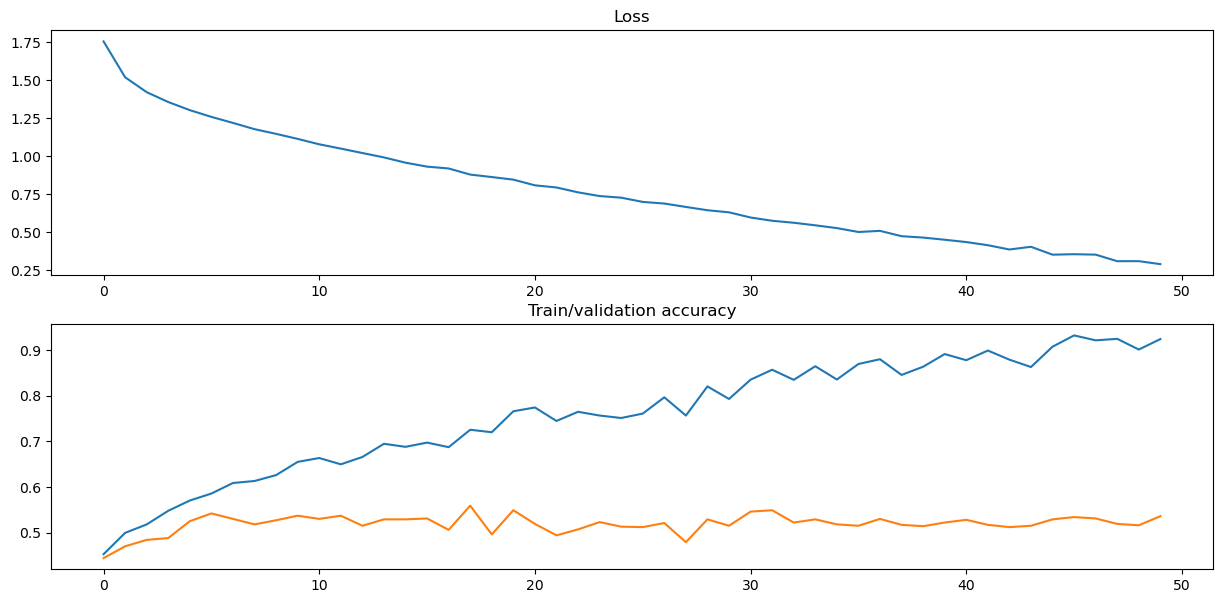

In [29]:
plt.figure(figsize=(15, 7))
plt.subplot(211)
plt.title("Loss")
plt.plot(loss_history)
plt.subplot(212)
plt.title("Train/validation accuracy")
plt.plot(train_history)
plt.plot(val_history)